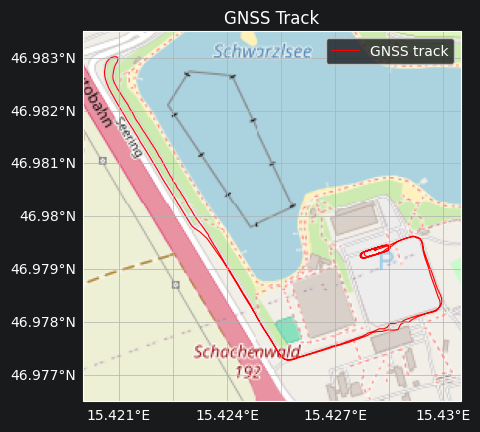

In [1]:
import settings
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

import importlib
importlib.reload(settings)

def read_gnss():
    raw = open(settings.gnss_file, 'r', encoding='iso-8859-1').readlines()
    gnss_data = [[float(val) for val in entry.split()] for entry in raw[1:]]
    gnss_data = np.array(gnss_data)
    return gnss_data

def plot_gnss(gnss_data, reference_data=None):
    cimgt_request = cimgt.OSM()
    ax = plt.axes(projection=cimgt_request.crs)
    ax.set_extent(settings.lat_lon_plotting_bounds)
    ax.add_image(cimgt_request, 15)

    plt.plot(gnss_data[:, 2], gnss_data[:, 1], transform=ccrs.Geodetic(), linewidth=0.8, color='red', label='GNSS track')
    if reference_data is not None:
        plt.plot(reference_data[:, 2], reference_data[:, 1], transform=ccrs.Geodetic(), linewidth=0.8, color='blue', label='Reference track')

    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False

    plt.title('GNSS Track')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend()
    plt.show()


gnss_data = read_gnss()
plot_gnss(gnss_data)


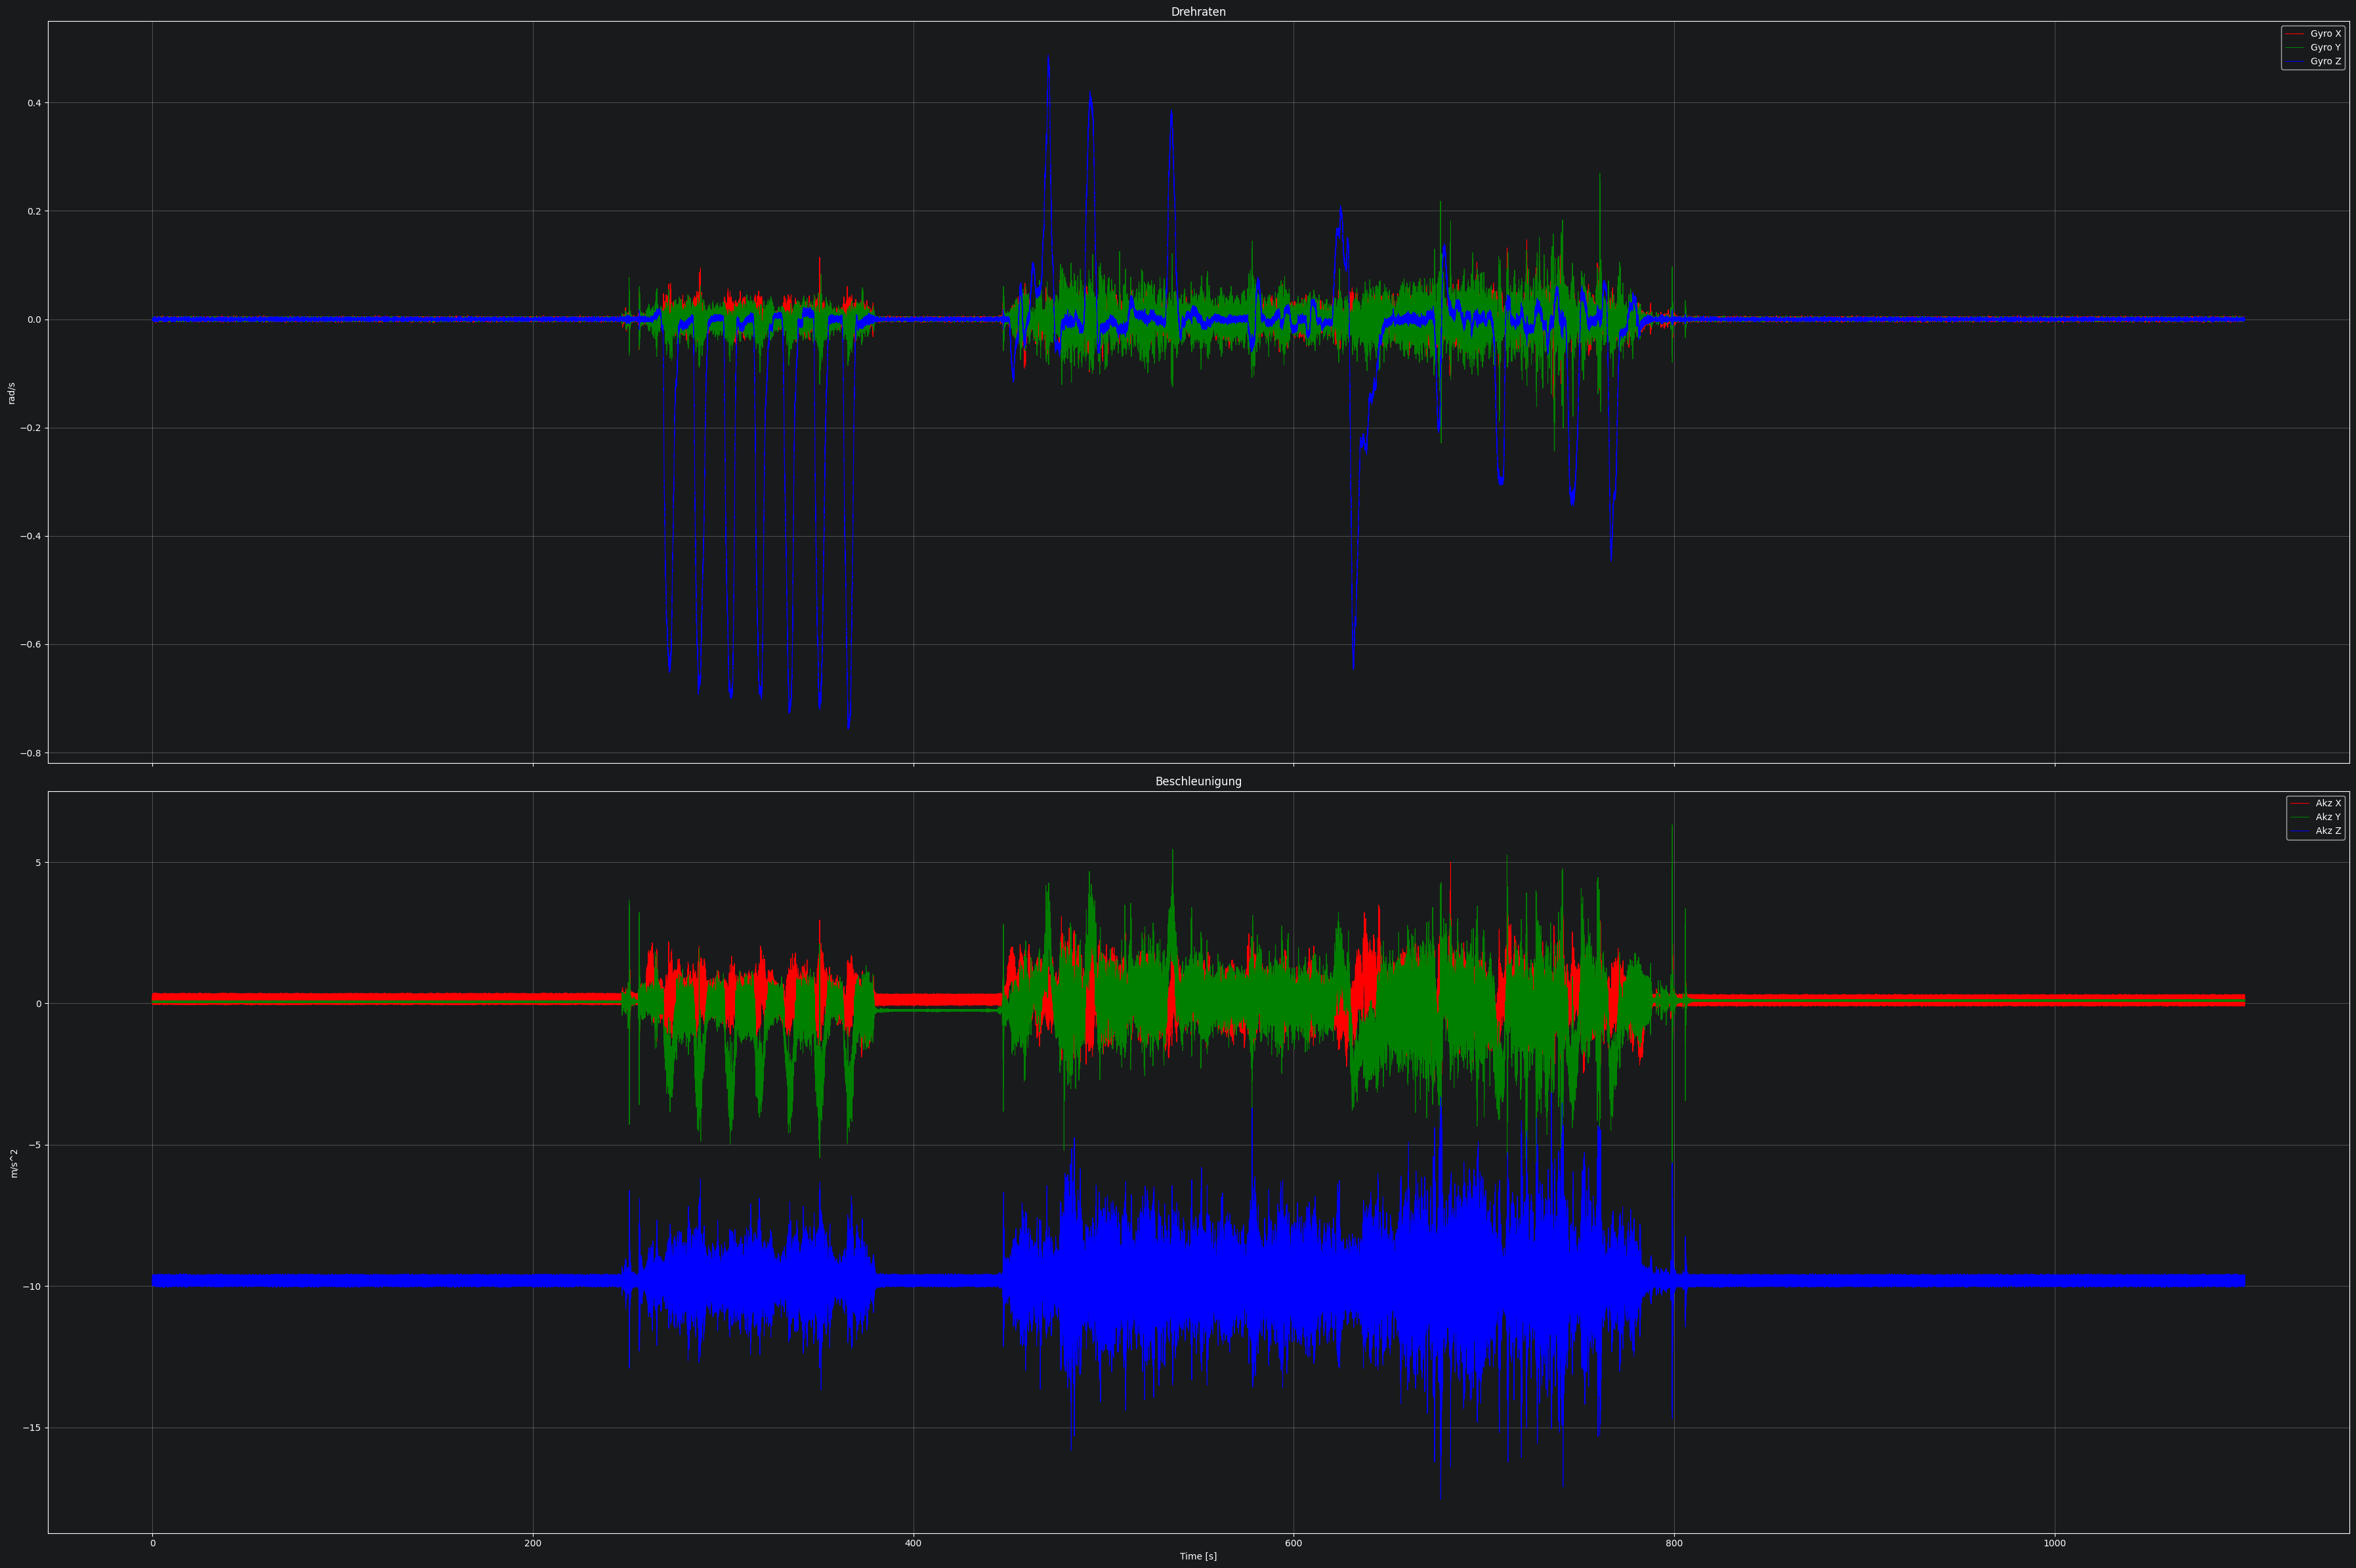

In [2]:

def read_imu():
    raw = open(settings.imu_file, 'r', encoding='iso-8859-1').readlines()
    imu_data = [[float(val) for val in entry.split()] for entry in raw[1:]]
    imu_data = np.array(imu_data)
    imu_data[:, [1, 2]] = imu_data[:, [2, 1]]
    imu_data[:, 3] *= -1
    imu_data[:, [1, 2, 3]] *= np.pi / 180.0
    imu_data[:, [4, 5]] = imu_data[:, [5, 4]]
    imu_data[:, 6] *= -1
    return imu_data


def plot_imu(imu_data, still_ranges=[]):
    time = imu_data[:, 0] - imu_data[0, 0]

    fig, axes = plt.subplots(2, 1, figsize=(36, 24), sharex=True)

    axes[0].plot(time, imu_data[:, 1], linewidth=0.8, color='red', label='Gyro X')
    axes[0].plot(time, imu_data[:, 2], linewidth=0.8, color='green', label='Gyro Y')
    axes[0].plot(time, imu_data[:, 3], linewidth=0.8, color='blue', label='Gyro Z')
    axes[0].set_title('Drehraten')
    axes[0].set_ylabel('rad/s')
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(time, imu_data[:, 4], linewidth=0.8, color='red', label='Akz X')
    axes[1].plot(time, imu_data[:, 5], linewidth=0.8, color='green', label='Akz Y')
    axes[1].plot(time, imu_data[:, 6], linewidth=0.8, color='blue', label='Akz Z')
    axes[1].set_title('Beschleunigung')
    axes[1].set_xlabel('Time [s]')
    axes[1].set_ylabel('m/s^2')
    axes[1].grid(True)
    axes[1].legend()

    for still_range in still_ranges:
        axes[0].axvspan(still_range[0] - imu_data[0, 0], still_range[1]  - imu_data[0, 0], color='gray', alpha=0.2)
        axes[1].axvspan(still_range[0] - imu_data[0, 0], still_range[1]  - imu_data[0, 0], color='gray', alpha=0.2)

    plt.tight_layout()
    plt.show()


imu_b_400hz = read_imu()
plot_imu(imu_b_400hz)


In [3]:
def process_imu(imu_data, window_time, function):
    smooth_indices = int(window_time * settings.imu_hz)
    window = (smooth_indices, 1)
    windows = np.lib.stride_tricks.sliding_window_view(imu_data, window)
    smoothed_imu_data = function(windows, axis=(-2, -1))
    return smoothed_imu_data

def smooth_imu(imu_data, window_time):
    return process_imu(imu_data, window_time, np.mean)

def max_imu(imu_data, window_time):
    return process_imu(imu_data, window_time, np.max)

def min_imu(imu_data, window_time):
    return process_imu(imu_data, window_time, np.min)

def undersample(data, factor):
    return data[::factor]

imu_b_01hz = smooth_imu(imu_b_400hz, 10.0)
imu_b_1hz = smooth_imu(imu_b_400hz, 1.0)
imu_b_5hz = smooth_imu(imu_b_400hz, 0.5)
imu_b_10hz = smooth_imu(imu_b_400hz, 0.1)
imu_b_50hz = smooth_imu(imu_b_400hz, 0.02)
imu_b_50hz_5 = undersample(imu_b_50hz, 5)
imu_b_100hz = smooth_imu(imu_b_400hz, 0.01)

In [4]:
importlib.reload(settings)
def get_still_data(imu_1hz, imu_data):
    imu_max = max_imu(imu_data, 1.0)
    imu_min = min_imu(imu_data, 1.0)
    imu_diff = imu_max - imu_min
    imu_diff[:, 0] = imu_1hz[:, 0]

    still_gyr = np.all(imu_diff[:, 1:4] < settings.still_gyr_threshold, axis=1)
    still_acc = np.all(imu_diff[:, 4:7] < settings.still_acc_threshold, axis=1)
    is_still = np.logical_and(still_gyr, still_acc)

    still_ranges = []
    start_range = None
    for i in range(len(is_still)):
        if is_still[i] and start_range is None:
            start_range = i
        elif (not is_still[i] or i == len(is_still) - 1) and start_range is not None:
            if imu_diff[i, 0] - imu_diff[start_range, 0] >= settings.min_still_time:
                still_ranges.append((start_range, i))
            else:
                print(f'Skipped range {start_range} - {i} because it was too short ({imu_diff[i, 0] - imu_diff[start_range, 0]}s)')
            start_range = None

    still_ranges = imu_1hz[still_ranges, 0] + np.array([settings.still_time_margin, -settings.still_time_margin])
    still_ranges[0, 0] = settings.min_plotting_time
    still_ranges[-1, 1] = settings.max_plotting_time
    return still_ranges

still_ranges = get_still_data(imu_b_1hz, imu_b_400hz)
print(f"Found {len(still_ranges)} still ranges: {str(still_ranges)}")

Skipped range 100882 - 101775 because it was too short (2.232526789972326s)
Skipped range 315417 - 315827 because it was too short (1.0250128225598019s)
Skipped range 316733 - 316744 because it was too short (0.02750033003394492s)
Skipped range 318549 - 318831 because it was too short (0.7050084601214621s)
Skipped range 320264 - 321453 because it was too short (2.97253666978213s)
Found 3 still ranges: [[221000.         221241.29085356]
 [221385.50248737 221441.31328809]
 [221812.27768339 222100.        ]]


In [5]:
phi_0 = gnss_data[0, 1] / 180.0 * np.pi
lambda_0 = gnss_data[0, 2] / 180.0 * np.pi
h_0 = gnss_data[0, 3]

In [6]:
def gamma(phi, h):
    gamma_phi = (
        settings.a * settings.gamma_a * np.cos(phi) ** 2 + settings.b * settings.gamma_b * np.sin(phi) ** 2
    ) / np.sqrt(
        settings.a ** 2 * np.cos(phi) ** 2 + settings.b ** 2 * np.sin(phi) ** 2
    )
    return gamma_phi * (
            1
            - 2 / settings.a * (
                    1 + settings.f + settings.m - 2 * settings.f * np.sin(phi) ** 2 * h
            )
            + 3 / (settings.a ** 2) * h ** 2
    )
g_0 = gamma(phi_0, h_0)

In [144]:
importlib.reload(settings)

def simple_plot(data):
    fig, ax = plt.subplots()
    ax.plot(data, linewidth=0.8)
    plt.show()

def single_plot(data, xmin=None, xmax=None, ymin=None, ymax=None):
    fig, ax = plt.subplots()
    ax.plot(data[:, 0], data[:, 1], linewidth=0.8)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    plt.show()

def triple_plot(data):
    fig, ax = plt.subplots()
    ax.plot(data[:, 0], linewidth=0.8, color='red')
    ax.plot(data[:, 1], linewidth=0.8, color='green')
    ax.plot(data[:, 2], linewidth=0.8, color='blue')
    plt.show()

def double_plot(data_a, data_b, xmin=None, xmax=None, ymin=None, ymax=None):
    fig, ax = plt.subplots()
    ax.plot(data_a[:, 0], data_a[:, 1], linewidth=0.4, color='red')
    ax.plot(data_b[:, 0], data_b[:, 1], linewidth=0.4, color='blue')
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    plt.show()

def coarse_alignment(imu_b_data, data_range, g_0, phi_0, lambda_0):
    imu_b_inrange = imu_b_data[np.logical_and(imu_b_data[:, 0] >= data_range[0], imu_b_data[:, 0] <= data_range[1]), :]
    avg_start_idx = np.argmax(imu_b_inrange[:, 0] > (data_range[1] - settings.coarse_alignment_time))

    acc_factor = np.array([1.0, 1.0, 1.0])
    gyr_factor = np.array([1.0, 1.0, 1.0])

    f_b_raw = imu_b_inrange[:, 4:7]
    omega_ib_b_raw = imu_b_inrange[:, 1:4]

    # unused: iterative coarse alignment
    # for i in range(settings.coarse_alignment_iterations):
    f_b = f_b_raw * acc_factor
    omega_ib_b = omega_ib_b_raw * gyr_factor
    c_b = np.cross(-f_b, omega_ib_b, axis=1)
    assert f_b.shape == omega_ib_b.shape == c_b.shape == (len(imu_b_inrange), 3)

    g_l = np.array([0, 0, g_0])
    omega_ie_l = np.array([
        settings.omega_e * np.cos(phi_0),
        0,
        - settings.omega_e * np.sin(phi_0),
    ])
    c_l = np.cross(g_l, omega_ie_l)
    assert g_l.shape == omega_ie_l.shape == c_l.shape == (3, )

    B = np.array([-f_b, omega_ib_b, c_b]).transpose((1, 2, 0))
    L = np.array([g_l, omega_ie_l, c_l]).T
    R_l_b_0  = B @ np.linalg.inv(L)
    R_b_l_0 = np.transpose(R_l_b_0, (0, 2, 1))

    pitch = np.arcsin(-R_b_l_0[:, 2, 0])
    roll = np.arctan2(R_b_l_0[:, 2, 1], R_b_l_0[:, 2, 2])
    yaw = np.arctan2(R_b_l_0[:, 1, 0], R_b_l_0[:, 0, 0])

    avg_start_idx = np.argmax(imu_b_inrange[:, 0] > (data_range[1] - settings.coarse_alignment_time))
    roll_avg = np.average(roll[avg_start_idx:])
    pitch_avg = np.average(pitch[avg_start_idx:])
    yaw_avg = np.average(yaw[avg_start_idx:])

    # print("Rotation matrix\n", R_l_b_0)
    # print("inverse", R_b_l_0)
    # print("rot times transpose")
    # print(R_l_b_0 @ R_b_l_0)
    # print("det")
    # print(np.linalg.det(R_l_b_0))

    # roll_avg = -0.3661 / 180.0 * np.pi
    # pitch_avg = 0.9121 / 180.0 * np.pi
    # yaw_avg = -108.3 / 180.0 * np.pi
    # # roll_avg = -0.363 / 180.0 * np.pi
    # # pitch_avg = 0.93 / 180.0 * np.pi
    # # yaw_avg = -100.0 / 180.0 * np.pi
    # print(f"Forced roll: {roll_avg}")
    # print(f"Forced pitch: {pitch_avg}")
    # print(f"Forced yaw: {yaw_avg}")

    # simple_plot(roll)
    # simple_plot(pitch)
    # simple_plot(yaw)
    # simple_plot(acc)

    R_b_l_0 = (np.array([
        [np.cos(yaw_avg), -np.sin(yaw_avg), 0],
        [np.sin(yaw_avg), np.cos(yaw_avg), 0],
        [0, 0, 1],
    ]) @
    np.array([
        [np.cos(pitch_avg), 0, np.sin(pitch_avg)],
        [0, 1, 0],
        [-np.sin(pitch_avg), 0, np.cos(pitch_avg)],
    ]) @
    np.array([
        [1, 0, 0],
        [0, np.cos(roll_avg), -np.sin(roll_avg)],
        [0, np.sin(roll_avg), np.cos(roll_avg)],
    ]))

    # compute acceleration factor based on expected earth gravity
    f_b_avg = np.average(f_b_raw[avg_start_idx:], axis=0)
    g_b = R_b_l_0.T @ g_l
    # acc_factor = acc_factor + (-g_b / f_b_avg - acc_factor) * settings.coarse_alignment_iteration_alpha
    acc_factor = -g_b / f_b_avg
    # print(f"Body gravity: {g_b} ({np.linalg.norm(g_b)} m/s^2)")
    # print(f"Average force: {f_b_avg} ({np.linalg.norm(f_b_avg)} m/s^2)")
    # print(f"Norm force times acceleration factor: {np.linalg.norm(f_b_avg * acc_factor)} m/s^2")

    # unused: gyroscope factoring
    omega_ib_b_avg = np.average(omega_ib_b_raw, axis=0)
    omega_ie_b = R_b_l_0.T @ omega_ie_l
    # gyr_factor = gyr_factor + (omega_ib_b_avg / omega_ie_b - gyr_factor) * settings.coarse_alignment_iteration_alpha
    gyr_factor = omega_ib_b_avg / omega_ie_b - gyr_factor

    print(f"Average roll: {roll_avg}")
    print(f"Average pitch: {pitch_avg}")
    print(f"Average yaw: {yaw_avg}")
    print(f"Acceleration factor: {acc_factor}")
    # print(f"Gyroscope factor: {gyr_factor}")
    # print(f"omega_ie_b: {omega_ie_b}")
    # print(f"omega_ib_b_avg: {omega_ib_b_avg}")
    # print(f"omega_ib_b_avg * factor: {omega_ib_b_avg * gyr_factor}")

    return (
        R_b_l_0,
        acc_factor,
        gyr_factor,
    )


R_b_l_0, acc_factor, gyr_factor = coarse_alignment(imu_b_01hz, [still_ranges[0][0], still_ranges[0][1]], g_0, phi_0, lambda_0)
# print(np.arcsin(-R_b_l_0[2, 0]))
# print(np.arctan2(R_b_l_0[2, 1], R_b_l_0[2, 2]))
# print(np.arctan2(R_b_l_0[1, 0], R_b_l_0[0, 0]))
# Average roll: -0.006357896200996419
# Average pitch: 0.015963623763695638
# Average yaw: -1.892086984717557

# f_b = imu_b_inrange[:, 4:7] * np.array([1.0, 1.00025376, 1.00025376])
# omega_ib_b = imu_b_inrange[:, 1:4] * np.array([0.99717809, 1.0, 0.99928742])

Average roll: -0.006357896200996419
Average pitch: 0.015963623763695638
Average yaw: -1.8921629926532324
Acceleration factor: [1.         1.00025376 1.00025376]


In [8]:
importlib.reload(settings)

def llh_to_ecef(phi, lamda, h):
    V = np.sqrt(1 + settings.e2 * np.cos(phi) ** 2)
    N = settings.c / V
    return np.array([
        (N + h) * np.cos(phi) * np.cos(lamda),
        (N + h) * np.cos(phi) * np.sin(lamda),
        ((settings.b ** 2 / settings.a ** 2) * N + h) * np.sin(phi),
    ])

def ecef_to_llh(xyz):
    if np.any(np.isnan(xyz)):
        return np.array([np.nan, np.nan, np.nan])
    p = np.sqrt(xyz[0] ** 2 + xyz[1] ** 2)
    h = np.nan
    phi = np.atan2(xyz[2] * settings.a ** 2, p * settings.b ** 2)
    while True:
        N_i = settings.c / np.sqrt(1 + settings.e2 * np.cos(phi) ** 2)
        h_i = p / np.cos(phi) - N_i
        phi_i = np.atan2(
            xyz[2] * (N_i + h_i),
            p * ((settings.b ** 2 / settings.a ** 2) * N_i + h_i)
        )
        if np.abs(phi_i - phi) < settings.phi_iteration_epsilon and np.abs(h_i - h) < settings.h_iteration_epsilon:
            phi = phi_i
            h = h_i
            break
        h = h_i
        phi = phi_i

    lamda = np.arctan2(xyz[1], xyz[0])
    return np.array([phi, lamda, h,])

def d_llh_to_d_ecef(llh, d_llh):
    V = np.sqrt(1 + settings.e2 * np.cos(llh[0]) ** 2)
    N = settings.c / V
    M = settings.c / V ** 3
    return np.array([
        (M + llh[2]) * d_llh[0],
        (N + llh[2]) * np.cos(llh[0]) * d_llh[1],
        -d_llh[2]
    ])

def d_ecef_to_d_llh(d_ecef, llh):
    V = np.sqrt(1 + settings.e2 * np.cos(llh[0]) ** 2)
    N = settings.c / V
    M = settings.c / V ** 3
    return np.array([
        d_ecef[0] / (M + llh[2]),
        d_ecef[1] / ((N + llh[2]) * np.cos(llh[0])),
        -d_ecef[2]
    ])

def rot_vector_to_array(rot_vector):
    return np.array([
        [0, -rot_vector[2], rot_vector[1]],
        [rot_vector[2], 0, -rot_vector[0]],
        [-rot_vector[1], rot_vector[0], 0],
    ])

def rot_array_to_vector(rot_array):
    return np.array([
        rot_array[2, 1],
        rot_array[0, 2],
        rot_array[1, 0],
    ])

def rot_matrix_to_rpy(rot_matrix):
    return np.array([
        np.arctan2(rot_matrix[1, 0], rot_matrix[0, 0]),
        np.arcsin(-rot_matrix[2, 0]),
        np.arctan2(rot_matrix[2, 1], rot_matrix[2, 2]),
    ])

x_e_0 = llh_to_ecef(phi_0, lambda_0, h_0)


In [145]:
from tqdm import tqdm

# strapdown_llh = strapdown(imu_b_50hz[::8], still_ranges, x_e_0, R_b_l_0)
imu_data = imu_b_100hz
# def strapdown(imu_data, still_ranges, x_e_0, R_b_l_0):
time = imu_data[:, 0]
f_b = imu_data[:, 4:7] * acc_factor
w_ib_b = imu_data[:, 1:4]

R_b_l = np.full((len(imu_data), 3, 3), np.nan)
R_b_l[0] = R_b_l_0
dR_b_l = np.full((len(imu_data), 3, 3), np.nan)
# dR_b_l[0] = np.zeros((3, 3))

x_e = np.full((len(imu_data), 3), np.nan)
x_e[0] = x_e_0
v_e_l = np.full((len(imu_data), 3), np.nan)
v_e_l[0] = np.zeros(3)
v_e_e = np.full((len(imu_data), 3), np.nan)

llh_e = np.full((len(imu_data), 3), np.nan)
llh_e[0] = ecef_to_llh(x_e[0])
dllh_e = np.full((len(imu_data), 3), np.nan)
# dllh_e[0] = np.zeros(3)

f_l = np.full((len(imu_data), 3), np.nan)
g_l = np.full((len(imu_data), 3), np.nan)
f_cor_l = np.full((len(imu_data), 3), np.nan)

w_il_l = np.full((len(imu_data), 3), np.nan)
w_lb_b = np.full((len(imu_data), 3), np.nan)
theta_lb_b = np.full((len(imu_data), 3), np.nan)

R_l_e = np.full((len(imu_data), 3, 3), np.nan)

for k in tqdm(range(0, len(imu_data) - 1), desc="Strapdown", unit="steps", unit_scale=True,):
    still = False
    for still_range in still_ranges:
        if still_range[0] <= time[k] <= still_range[1]:
            still = True
            break

    if not still:
        # step 0 - prepare data
        llh_e[k] = ecef_to_llh(x_e[k])
        dllh_e[k] = d_ecef_to_d_llh(v_e_l[k], llh_e[k])


        # step 1 - compute R_b_l
        # 1a
        w_il_l[k] = np.array([
            (dllh_e[k, 1] + settings.omega_e) * np.cos(llh_e[k, 0]),
            -dllh_e[k, 0],
            -(dllh_e[k, 1] + settings.omega_e) * np.sin(llh_e[k, 0]),
        ])
        Omega_il_l = rot_vector_to_array(w_il_l[k])
        Omega_ib_b = rot_vector_to_array(w_ib_b[k])
        Omega_lb_b = Omega_ib_b - R_b_l[k].T @ Omega_il_l @ R_b_l[k]
        w_lb_b[k] = rot_array_to_vector(Omega_lb_b)
        theta_lb_b[k] = w_lb_b[k] * (time[k + 1] - time[k])

        # TODO check indices
        # 1b
        Theta_lb_b = rot_vector_to_array(theta_lb_b[k])
        theta_lb_b_norm = np.linalg.norm(theta_lb_b[k])
        A_lb_b = np.eye(3) + np.sin(theta_lb_b_norm) / theta_lb_b_norm * Theta_lb_b + (1 - np.cos(theta_lb_b_norm)) / theta_lb_b_norm ** 2 * Theta_lb_b @ Theta_lb_b
        R_b_l[k + 1] = R_b_l[k] @ A_lb_b

        # step 2 - transform f_b
        f_l[k + 1] = R_b_l[k + 1] @ f_b[k + 1]

        # step 3 - calculate normal gravity
        g_l[k] = np.array([
            0, 0, gamma(llh_e[k, 0], llh_e[k, 2])
        ])

        # step 4 - compute coriolis force
        w_ie_l = np.array([
            settings.omega_e * np.cos(llh_e[k, 0]),
            0,
            - settings.omega_e * np.sin(llh_e[k, 0]),
        ])
        f_cor_l[k] = np.cross(-(w_il_l[k] + w_ie_l), v_e_l[k])

        # step 5 - compute acceleration and speed
        dv_e_l = f_l[k + 1] + f_cor_l[k] + g_l[k]
        v_e_l[k + 1] = dv_e_l * (time[k + 1] - time[k]) + v_e_l[k]

        # step 6 - compute position
        north_e = np.array([
            -np.sin(llh_e[k, 0]) * np.cos(llh_e[k, 1]),
            -np.sin(llh_e[k, 0]) * np.sin(llh_e[k, 1]),
            np.cos(llh_e[k, 0]),
        ])
        east_e = np.array([
            -np.sin(llh_e[k, 1]),
            np.cos(llh_e[k, 1]),
            0,
        ])
        down_e = np.array([
            -np.cos(llh_e[k, 0]) * np.cos(llh_e[k, 1]),
            -np.cos(llh_e[k, 0]) * np.sin(llh_e[k, 1]),
            -np.sin(llh_e[k, 0]),
        ])
        R_l_e[k] = np.array([north_e, east_e, down_e]).T

        v_e_e[k + 1] = R_l_e[k] @ v_e_l[k + 1]
        x_e[k + 1] = x_e[k] + v_e_e[k + 1] * (time[k + 1] - time[k])
    else:
        # standstill - copy values from previous epoch
        if k > 0:
            llh_e[k] = llh_e[k - 1]
        else:
            llh_e[k] = ecef_to_llh(x_e[0])
        dllh_e[k] = 0

        R_b_l[k + 1] = R_b_l[k]
        dR_b_l[k + 1] = 0
        x_e[k + 1] = x_e[k]
        v_e_l[k + 1] = 0
        f_l[k + 1] = R_b_l[k + 1] @ f_b[k + 1]

gnss_plot_data = np.hstack((time[:, None], llh_e * np.array([180.0 / np.pi, 180.0 / np.pi, 1.0])))

# pitch = np.arcsin(-R_b_l[:, 2, 0])
# roll = np.arctan2(R_b_l[:, 2, 1], R_b_l[:, 2, 2])
# yaw = np.arctan2(R_b_l[:, 1, 0], R_b_l[:, 0, 0])
# simple_plot(roll)
# simple_plot(pitch)
# simple_plot(yaw)
# simple_plot(llh_e[:, 0])
# simple_plot(llh_e[:, 1])
# simple_plot(llh_e[:, 2])
# simple_plot(f_l[:, 0])
# simple_plot(f_l[:, 1])
# simple_plot(f_l[:, 2])
# triple_plot(theta_lb_b)

# strapdown_llh = strapdown(imu_b_50hz[::8], still_ranges, x_e_0, R_b_l_0, acc_factor)


Strapdown: 100%|██████████| 440k/440k [00:45<00:00, 9.69ksteps/s] 


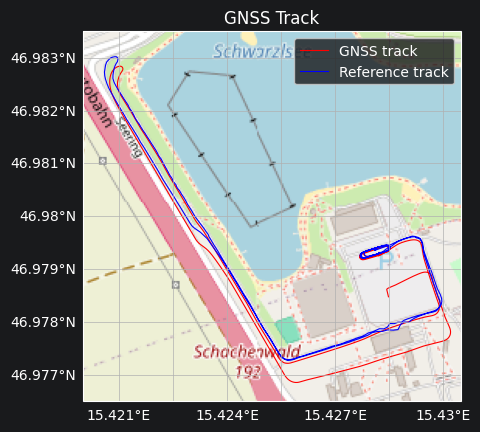

height


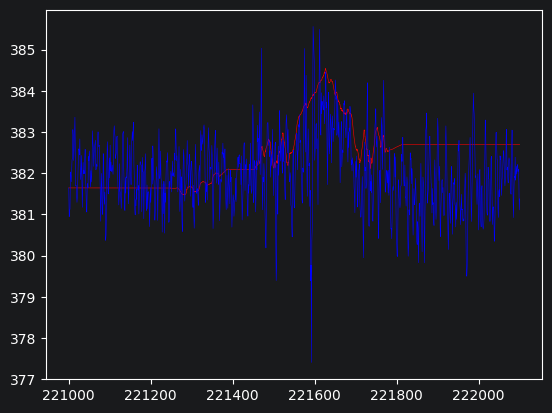

lat


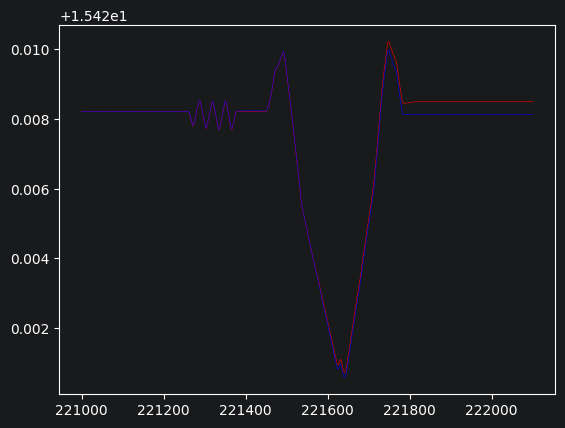

lon


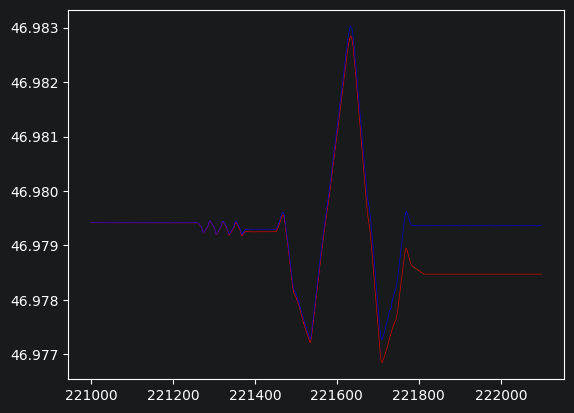

In [146]:
# print("force local")
# single_plot(np.stack([imu_data[:, 0], f_l[:, 0]]).T, ymin=-0.025, ymax=0.025)
# single_plot(np.stack([imu_data[:, 0], f_l[:, 1]]).T, ymin=-0.1, ymax=0.1)
# single_plot(np.stack([imu_data[:, 0], f_l[:, 2]]).T)
# print("gravity")
# single_plot(np.stack([imu_data[:, 0], g_l[:, 2]]).T, ymin=9.7, ymax=9.9)
# print("coriolis")
# single_plot(np.stack([imu_data[:, 0], f_cor_l[:, 0]]).T,)
# single_plot(np.stack([imu_data[:, 0], f_cor_l[:, 1]]).T,)
# single_plot(np.stack([imu_data[:, 0], f_cor_l[:, 2]]).T,)
# print("force corrected")
# single_plot(np.stack([imu_data[:, 0], f_l[:, 2] + g_l[:, 2] + f_cor_l[:, 2]]).T, ymin=-0.1, ymax=0.1)

# print("speed local")
# single_plot(np.stack([imu_data[:, 0], v_e_l[:, 0]]).T)
# single_plot(np.stack([imu_data[:, 0], v_e_l[:, 1]]).T)
# single_plot(np.stack([imu_data[:, 0], v_e_l[:, 2]]).T)
# print("speed global")
# single_plot(np.stack([imu_data[:, 0], v_e_e[:, 0]]).T)
# single_plot(np.stack([imu_data[:, 0], v_e_e[:, 1]]).T)
# single_plot(np.stack([imu_data[:, 0], v_e_e[:, 2]]).T)
# print("position ecef")
# single_plot(np.stack([imu_data[:, 0], x_e[:, 0]]).T)
# single_plot(np.stack([imu_data[:, 0], x_e[:, 1]]).T)
# single_plot(np.stack([imu_data[:, 0], x_e[:, 2]]).T)
# print("distance from earth center")
# single_plot(np.stack([imu_data[:, 0], np.linalg.norm(x_e, axis=1)]).T)

R_l_e_rpy = rot_matrix_to_rpy(R_l_e.transpose(1, 2, 0)).T
# print("R_l_e rpy")
# double_plot(np.stack([imu_data[:, 0], 180 - R_l_e_rpy[:, 0] * 180 / np.pi]).T, gnss_data[:, [0, 2]] * np.nan)
# double_plot(np.stack([imu_data[:, 0], -R_l_e_rpy[:, 1] * 180 / np.pi]).T, gnss_data[:, [0, 1]] * np.nan)
# double_plot(np.stack([imu_data[:, 0], -R_l_e_rpy[:, 2] * 180 / np.pi]).T, gnss_data[:, [0, 1]] * np.nan)

plot_gnss(gnss_plot_data[::10], reference_data=gnss_data)
print("height")
double_plot(np.stack([imu_data[:, 0], llh_e[:, 2]]).T, gnss_data[:, [0, 3]])
print("lat")
double_plot(np.stack([imu_data[:, 0], llh_e[:, 1] * 180 / np.pi]).T, gnss_data[:, [0, 2]])
print("lon")
double_plot(np.stack([imu_data[:, 0], llh_e[:, 0] * 180 / np.pi]).T, gnss_data[:, [0, 1]])
